# Empire Wind 2Working Analysis

This analysis notebook should be considered under construction while assumptions are brought up to date, and the model is refined

## Imports and environment set up

In [1]:
from pathlib import Path
from itertools import product

import pandas as pd
import matplotlib.pyplot as plt

from whale import Project

pd.options.display.float_format = '{:,.4f}'.format
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

## Determine the configurations and create a Project

**NOTE**: Make sure in the WOMBAT config files that the library path is the same that gets printed in this first code block when you run the notebook

In [2]:
project_name = "Empire Wind 2"

library_path = Path("library").resolve()
orbit_config = f"{project_name.replace(' ', '_')}_base_install.yaml"
wombat_config = f"{project_name.replace(' ', '_')}_base_operations.yaml"
floris_config = f"{project_name.replace(' ', '_')}_base_floris_jensen.yaml"

In [3]:
project = Project(

    # Basic Model Configurations
    library_path=library_path,
    weather_profile=library_path / "weather" / "ocean_wind_1_39.0_-74.0_1959_2023.csv",
    orbit_config=orbit_config,
    wombat_config=wombat_config,
    floris_config=floris_config,
    
    # Used for the connecting ORBIT to the weather profile
    orbit_weather_cols=["windspeed_100m", "windspeed_10m", "waveheight"],
    
    # Connecting FLORIS with the weather data and WOMBAT for wind conditions and layout
    floris_windspeed="windspeed_100m",
    floris_wind_direction="wind_direction_100m",
    floris_x_col="floris_x",
    floris_y_col="floris_y",
    
    # Financial Assumptions
    discount_rate=0.025,
    offtake_price=107.50,
    fixed_charge_rate=0.0582,  # 2021 COE Review for Fixed-Bottom OSW
    loss_ratio=0.1,  # Non-wake and non-availability attributed losses
    
    # CapEx Date Application Settings
    orbit_start_date="1/1/1998",  # Starting date for installations if set to 0
    # Dates to evenly distribute the varying non-installation CapEx costs per category as
    # (year, month) integer pairs, or a list of tuples, as seen below
    soft_capex_date=(1995, 1), 
    project_capex_date=[(1996, 1), (1996, 7), (1997, 1), (1997, 7)],
    system_capex_date=list(product(range(1996, 2000), (1, 4, 7, 10))), # quarterly over 2 years
    turbine_capex_date=list(product(range(1996, 2000), (1, 4, 7, 10))), # quarterly over 2 years

    # After the first run with a layout file this isn't needed because the default (True) won't fail
    connect_floris_to_layout= True,  # True: connect WOMBAT & FLORIS layout configurations
    connect_orbit_array_design= True,  # True: connect WOMBAT & ORBIT layout configurations
    
)


ORBIT library intialized at '/Users/rhammond/Documents/GitHub/WHaLE/examples/library'


FileNotFoundError: [Errno 2] No such file or directory: '/Users/rhammond/Documents/GitHub/WHaLE/examples/library/windfarm/tbd.csv'

In [ ]:
# # Run these for the first iteration only

# # Calculate the relative distance FLORIS layout
# project.generate_floris_positions_from_layout(
#     x_col="easting",
#     y_col="northing",
#     update_config=True,  # update the model and configuration
#     config_fname=floris_config,  # save over the original
# )
# project.connect_floris_to_turbines(x_col="floris_x", y_col="floris_y")

# # Once ORBIT issues are resolved, and feature branch is merged into develop this can be used
# project.connect_orbit_cable_lengths()

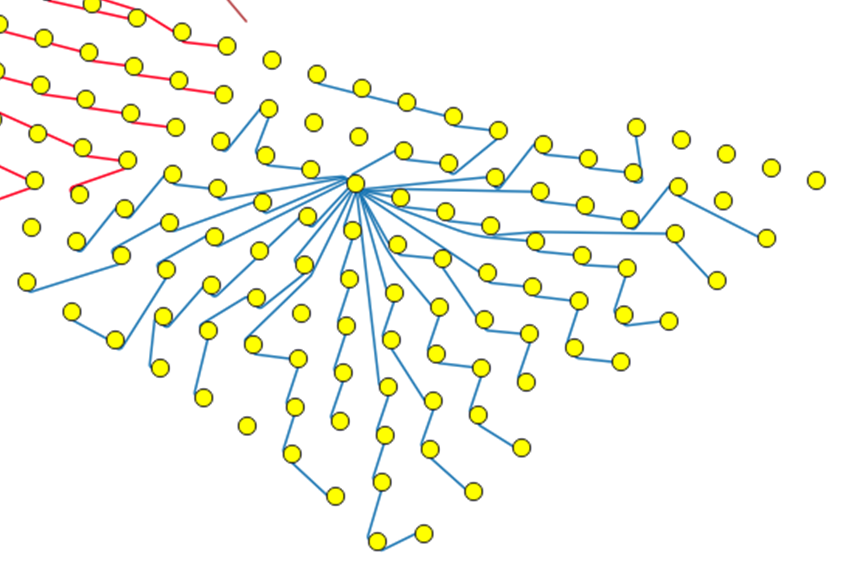 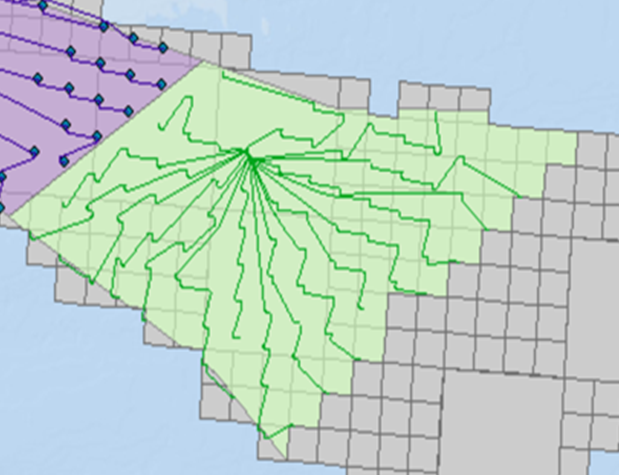

In [ ]:
# Inspect the layout
fig, ax = project.plot_farm(return_fig=True)
fig.savefig(library_path / "results" / f"{project_name.lower().replace(' ', '_')}.svg")
fig.savefig(library_path / "results" / f"{project_name.lower().replace(' ', '_')}.png")

## Run the analyses and calculate results

This separately calls the `run` methods for each of the ORBIT `ProjectManager` and WOMBAT `Simulation`, in that order. Alternatively, these could just be called on their own, just like we must with FLORIS for the time being.


In [ ]:
project.run(
    which_floris="wind_rose",
    full_wind_rose=False,
    floris_reinitialize_kwargs=dict(cut_in_wind_speed=3.0, cut_out_wind_speed=25.0)
)
project.wombat.env.cleanup_log_files()  # Delete logging data from WOMBAT

## Results

### Generate the high-level metrics

#### Generate the standard reporting metrics

In [ ]:
metrics_configuration = {
    "# Turbines": {"metric": "n_turbines", "kwargs": {}},
    "Turbine Rating (MW)": {"metric": "turbine_rating", "kwargs": {}},
    "Project Capacity (MW)": {"metric": "capacity", "kwargs": {"units": "mw"}},
    "# OSS": {"metric": "n_substations", "kwargs": {}},
    "Total Export Cable Length (km)": {"metric": "export_system_total_cable_length", "kwargs": {}},
    "Total Array Cable Length (km)": {"metric": "array_system_total_cable_length", "kwargs": {}},
    "CapEx ($)": {"metric": "capex", "kwargs": {}},
    "CapEx per kW ($/kW)": {"metric": "capex", "kwargs": {"per_capacity": "kw"}},
    "OpEx ($)": {"metric": "opex", "kwargs": {}},
    "OpEx per kW ($/kW)": {"metric": "opex", "kwargs": {"per_capacity": "kw"}},
    "AEP (MWh)": {
        "metric": "energy_production",
        "kwargs": {"units": "mw", "aep": True, "with_losses": True}
    },
    "AEP per kW (MWh/kW)": {
        "metric": "energy_production",
        "kwargs": {"units": "mw", "per_capacity": "kw", "aep": True, "with_losses": True}
    },
    "Net Capacity Factor Without Unmodeled Losses (%)": {
        "metric": "capacity_factor",
        "kwargs": {"which": "net"}
    },
    "Net Capacity Factor With All Losses (%)": {
        "metric": "capacity_factor",
        "kwargs": {"which": "net", "with_losses": True}
    },
    "Gross Capacity Factor (%)": {"metric": "capacity_factor", "kwargs": {"which": "gross"}},
    "LCOE ($/MWh)": {"metric": "lcoe", "kwargs": {}},
    "IRR (%)": {"metric": "irr", "kwargs": {}},
    "NPV ($)": {"metric": "npv", "kwargs": {}},
}
report_df = project.generate_report(metrics_configuration, project_name).T

#### Generate the non-standard or input-based metrics

In [ ]:
export_system = project.orbit.system_costs["ExportCableInstallation"]
export_installation = project.orbit.installation_costs["ExportCableInstallation"]
capex_sans_export = project.orbit.total_capex - export_system - export_installation
additional_reporting = pd.DataFrame(
    [
        ["FCR (%)", project.fixed_charge_rate],
        ["Offtake Price ($/MWh)", project.offtake_price],
        ["System CapEx for Export Cables ($)", export_system],
        ["Installation CapEx for Export Cables ($)", export_installation],
        ["CapEx Without Export Cables ($)", capex_sans_export],
        ["Annual OpEx per kW ($/kW)", report_df.loc["OpEx per kW ($/kW)", project_name] / project.operations_years],
    ],
    columns=["Project"] + report_df.columns.tolist(),
).set_index("Project")

#### Combine, save, and display the results

In [ ]:
metrics_order = [
    "# Turbines",
    "Turbine Rating (MW)",
    "Project Capacity (MW)",
    "# OSS",
    "Total Export Cable Length (km)",
    "Total Array Cable Length (km)",
    "FCR (%)",
    "Offtake Price ($/MWh)",
    "CapEx ($)",
    "CapEx per kW ($/kW)",
    "System CapEx for Export Cables ($)",
    "Installation CapEx for Export Cables ($)",
    "CapEx Without Export Cables ($)",
    "OpEx ($)",
    "OpEx per kW ($/kW)",
    "Annual OpEx per kW ($/kW)",
    "Gross Capacity Factor (%)",
    "Net Capacity Factor Without Unmodeled Losses (%)",
    "Net Capacity Factor With All Losses (%)",
    "AEP (MWh)",
    "AEP per kW (MWh/kW)",
    "LCOE ($/MWh)",
    "IRR (%)",
    "NPV ($)",
]
report_df = pd.concat((report_df, additional_reporting), axis=0).loc[metrics_order]
report_df.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_metrics.csv", index_label="Metrics")

In [ ]:
report_df

### Generate the monthly outputs for detailed review

In [ ]:
monthly_results = project.cash_flow(breakdown=True).join(project.energy_production(frequency="month-year")).fillna(0)
monthly_results = monthly_results.assign(
    CapEx_Installation=monthly_results[[c for c in monthly_results if c.startswith("CapEx") and c.endswith("Installation")]].sum(axis=1),
    CapEx_System=monthly_results[[c for c in monthly_results if c.startswith("CapEx") and c.endswith("System")]].sum(axis=1),
)
monthly_results.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_monthly_detailed_results.csv")
monthly_results

In [ ]:
final_cols = ["CapEx ($)", "OpEx ($)", "Energy Production (GWh)", "Revenue ($)", "Cash Flow ($)"]
monthly_results["CapEx ($)"] = monthly_results[["CapEx_Installation", "CapEx_Soft", "CapEx_Project", "CapEx_System", "CapEx_Turbine"]].sum(axis=1)
monthly_results = monthly_results.rename(columns={"OpEx": "OpEx ($)","Revenue": "Revenue ($)", "cash_flow": "Cash Flow ($)"})[final_cols]
monthly_results.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_monthly_results.csv")
monthly_results

## Inputs Summary

In [ ]:
inputs = pd.DataFrame(
    [
        ["FCR", project.fixed_charge_rate],
        ["Offtake price ($/MWh)", project.offtake_price],
        ["Lease Area Price ($)", "??"],
        ["Discount rate (%)", project.discount_rate],
        ["# Turbines", project.n_turbines()],
        ["Turbine Rating (MW)", project.turbine_rating()],
        ["Project Capacity (MW)", project.capacity("mw")],
        ["# OSS", project.n_substations()],
        ["Substructure type", "??"],
        ["Row spacing (rotor diameters)", "not used for custom layouts"],
        ["Turbine spacing (rotor diameters)", "not used for custom layouts"],
        ["Depth (m)", project.orbit.config["site"]["depth"]],
        [
            "Mean wind speed (m/s)",
            project.weather.loc[
                project.orbit_start_date: project.wombat.env.end_datetime,
                "windspeed_100m"
            ].mean()
        ],
        ["Distance to landfall (km)", project.orbit.config["site"]["distance_to_landfall"]],
        ["Distance to port (km)", project.wombat.config.port_distance],
        ["Interconnection distance (km)", project.orbit._phases["ExportSystemDesign"]._distance_to_interconnection],
        ["# of POIs", "??"],
        ["Export cable type", [*project.orbit._phases["ExportSystemDesign"].cable_lengths_by_type]],
        ["Array cable type", [*project.orbit._phases["CustomArraySystemDesign"].cable_lengths_by_type]],
    ],
    columns=["Inputs", f"{project_name}"]
).set_index("Inputs")
inputs.to_csv(library_path / "results" / f"{project_name.lower().replace(' ', '_')}_inputs.csv")
inputs